# Login and Install

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#%cd /content/drive/MyDrive/GenAI/Project/GenAI_Project/SISO_reimplemented
# Gorkem
%cd /content/drive/Othercomputers/'My MacBook Pro'/SISO_original/SISO_reimplemented

/content/drive/Othercomputers/My MacBook Pro/SISO_original/SISO_reimplemented


In [4]:
import os
!pip install torch>=1.9 torchvision ftfy regex huggingface_hub
!pip install -q diffusers matplotlib accelerate peft kornia tqdm
!pip install -q git+https://github.com/mlfoundations/open_clip


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Configuration

In [5]:
import open_clip
import torch
custom_config = open_clip.get_model_config("ViT-H-14")
custom_config["vision_cfg"]["image_size"] = 336

# Register it under the paper's name
open_clip.factory._MODEL_CONFIGS["ViT-H-14-290"] = custom_config
print(open_clip.factory._MODEL_CONFIGS['ViT-H-14-290'])

gradient_accumulation_steps = 1
max_train_steps = 1000
num_train_epochs = 100

LR = 2E-4
lr_scheduler_type = "constant"
lr_warmup_steps = 0

ADAM_BETAS = (0.9, 0.999)
ADAM_WEIGHT_DECAY = 1e-2
ADAM_EPSILON = 1e-8

LORA_RANK = 8
LORA_ALPHA = 4

dino_weight = 1.0
ir_weight = 1.0
device = "cuda" if torch.cuda.is_available() else "cpu"

{'embed_dim': 1024, 'vision_cfg': {'image_size': 336, 'layers': 32, 'width': 1280, 'head_width': 80, 'patch_size': 14}, 'text_cfg': {'context_length': 77, 'vocab_size': 49408, 'width': 1024, 'heads': 16, 'layers': 24}}


# Setup

In [6]:
dino_file_check = os.path.exists("./dino_utils.py") and os.path.isfile("./dino_utils.py")
ir_file_check = os.path.exists("./ir_features_utils.py") and os.path.isfile("./ir_features_utils.py")
general_file_check = os.path.exists("./general_utils.py") and os.path.isfile("./general_utils.py")
assert (dino_file_check and ir_file_check and general_file_check), "Not all files are present"

import gc
import os
from PIL import Image
import numpy as np
from transformers import CLIPTextModel, CLIPTokenizer, CLIPTextModelWithProjection
from diffusers import (
    DDPMScheduler,
    DiffusionPipeline,
    AutoencoderKL,
    UNet2DConditionModel
)
from pipeline_stable_diffusion_xl_with_grads import StableDiffusionXLPipelineWithGrads
import torch
import torchvision
from peft import LoraConfig, get_peft_model
from accelerate import Accelerator
import matplotlib.pyplot as plt
from pprint import pprint
from tqdm import tqdm, trange
from diffusers.optimization import get_scheduler

import dino_utils as dino_utils
import ir_features_utils as ir_features_utils
import general_utils as general_utils

In [7]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("louieshao/guieweights0732")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/guieweights0732


## Generation Models

In [8]:
accelerator = Accelerator(gradient_accumulation_steps=gradient_accumulation_steps)

In [9]:
model_path = "stabilityai/sdxl-turbo"
"""
  Refer to
    https://huggingface.co/docs/diffusers/en/training/lora
    https://github.com/huggingface/diffusers/blob/e4b8f173b97731686e290b2eb98e7f5df2b1b322/examples/text_to_image/train_text_to_image_lora.py

"""

noise_scheduler = DDPMScheduler.from_pretrained(model_path, subfolder="scheduler")
tokenizer = CLIPTokenizer.from_pretrained(model_path, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_path, subfolder="text_encoder")
text_encoder_2 = CLIPTextModelWithProjection.from_pretrained(model_path, subfolder="text_encoder_2")
unet = UNet2DConditionModel.from_pretrained(model_path, subfolder="unet")
vae = AutoencoderKL.from_pretrained(model_path, subfolder="vae")

vae.requires_grad_(False)
text_encoder.requires_grad_(False)
text_encoder_2.requires_grad_(False)
unet.requires_grad_(False)

lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)

unet.add_adapter(lora_config)
# vae.add_adapter(lora_config)
lora_layers = list(filter(lambda p: p.requires_grad, unet.parameters()))

optimizer = torch.optim.AdamW(
    lora_layers,
    lr=LR,
    betas=ADAM_BETAS,
    weight_decay=ADAM_WEIGHT_DECAY,
    eps=ADAM_EPSILON
)

lr_scheduler = get_scheduler(
    lr_scheduler_type,
    optimizer=optimizer,
    num_warmup_steps=lr_warmup_steps * gradient_accumulation_steps,
    num_training_steps=num_train_epochs,
)
unet, optimizer, lr_scheduler = accelerator.prepare(unet, optimizer, lr_scheduler)
# unet, vae, optimizer = accelerator.prepare(unet, vae, optimizer)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Loss Models

In [10]:
## dino model and loss function
dino_model_path = "vit_large_patch14_dinov2.lvd142m"
dino_criterion  = dino_utils.get_dino_features_negative_mean_cos_sim
dino, transforms_configs = (dino_utils.get_model_and_transforms_configs(dino_model_path))

## IR model and Loss function
new_path = path + "/arcface all vith 18 last and middle first 3 280 all 3 290 first 1 overlap last 6 middle 6 first 3 dropout.pth"

ir_criterion = ir_features_utils.get_ir_features_negative_mean_cos_sim
ir_feature_extractor, feature_extractor_transforms = (
          ir_features_utils.get_ir_model_and_transforms(
              new_path,
              device=device
          )
      )
ir_feature_extractor = ir_feature_extractor.to(device)
ir_feature_extractor.eval()


add_layer_model(
  (backbone): VisionTransformer(
    (conv1): Conv2d(3, 1280, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-31): 32 x ResidualAttentionBlock(
          (ln_1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1280, out_features=1280, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1280, out_features=5120, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=5120, out_features=1280, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((1280,), eps=1e-

## Mask Detection Models

In [8]:
from transformers import pipeline
import torchvision.transforms as T
from transformers import SamModel, SamProcessor
import mask_utils as mask_utils

object_detector = pipeline(
    task="zero-shot-object-detection",
    model="IDEA-Research/grounding-dino-tiny",
    device=device
)

sam_model = SamModel.from_pretrained("facebook/sam-vit-huge").to(device)
sam_processor = SamProcessor.from_pretrained("facebook/sam-vit-huge")

get_mask = mask_utils.get_mask

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda


# Dataset

In [11]:
dataset_path = './../dreambooth/dreambooth/dataset'
total_images = 0

# Loop through all subdirectories in the dataset folder

print("Object-wise image counts:\n")

for obj_name in os.listdir(dataset_path):
    obj_path = os.path.join(dataset_path, obj_name)
    # Skip non-directories
    if not os.path.isdir(obj_path):
        continue
    # Count image files (basic check for common image extensions)
    image_count = sum(
        1 for file in os.listdir(obj_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'))
    )
    print(f"{obj_name}: {image_count}")
    total_images += image_count

print("\nTotal number of images:", total_images)

Object-wise image counts:

backpack: 6
backpack_dog: 5
bear_plushie: 5
berry_bowl: 6
can: 6
candle: 5
cat: 5
cat2: 5
clock: 6
colorful_sneaker: 5
dog: 5
dog2: 6
dog3: 6
dog5: 5
dog6: 5
dog7: 5
dog8: 5
duck_toy: 4
fancy_boot: 6
grey_sloth_plushie: 5
monster_toy: 5
pink_sunglasses: 6
poop_emoji: 5
rc_car: 5
red_cartoon: 4
robot_toy: 5
shiny_sneaker: 6
teapot: 5
vase: 6
wolf_plushie: 5

Total number of images: 158


## Recenter and crop all images to get 512 x 512 images

In [12]:
dataset_path = './../dreambooth/dreambooth/dataset'
image_dict = {}

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue  # Skip non-folders

    image_dict[folder] = {}
    img_index = 0

    if folder == 'cat2' or folder == 'backpack':
      for filename in sorted(os.listdir(folder_path)):
          if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
              img_path = os.path.join(folder_path, filename)
              try:
                  img = general_utils.load_image(img_path)
                  processed_img = general_utils.resize_and_center_crop(img)
                  image_dict[folder][img_index] = processed_img
                  img_index += 1
              except Exception as e:
                  print(f"Error loading {img_path}: {e}")

print("Loaded images from folders.")

Loaded images from folders.


In [13]:
print(image_dict)

{'backpack': {0: <PIL.Image.Image image mode=RGB size=512x512 at 0x794163FE0290>, 1: <PIL.Image.Image image mode=RGB size=512x512 at 0x7941641E3C10>, 2: <PIL.Image.Image image mode=RGB size=512x512 at 0x79414C606E90>, 3: <PIL.Image.Image image mode=RGB size=512x512 at 0x79414C607F50>, 4: <PIL.Image.Image image mode=RGB size=512x512 at 0x79414C605A10>, 5: <PIL.Image.Image image mode=RGB size=512x512 at 0x79414C606790>}, 'backpack_dog': {}, 'bear_plushie': {}, 'berry_bowl': {}, 'can': {}, 'candle': {}, 'cat': {}, 'cat2': {0: <PIL.Image.Image image mode=RGB size=512x512 at 0x79414C606E10>, 1: <PIL.Image.Image image mode=RGB size=512x512 at 0x79414C607010>, 2: <PIL.Image.Image image mode=RGB size=512x512 at 0x79414C624410>, 3: <PIL.Image.Image image mode=RGB size=512x512 at 0x79414C607390>, 4: <PIL.Image.Image image mode=RGB size=512x512 at 0x79414C606F50>}, 'clock': {}, 'colorful_sneaker': {}, 'dog': {}, 'dog2': {}, 'dog3': {}, 'dog5': {}, 'dog6': {}, 'dog7': {}, 'dog8': {}, 'duck_toy': {

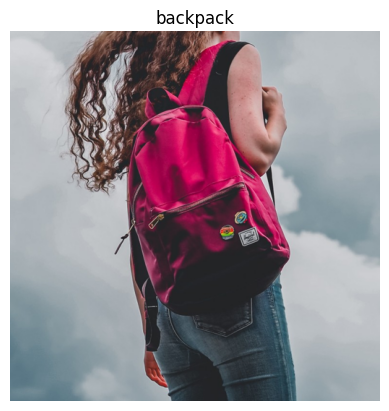

(512, 512)


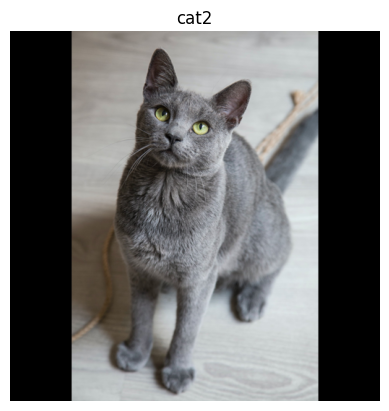

(512, 512)


In [14]:
for class_name, images in image_dict.items():
    if 0 in images:
        img = images[0]  # Get the first image
        plt.figure()
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
        plt.show()
        print(img.size)

# Generation Images
Process to generate an image:
1. Take a random noise vector in latent space zT
2. denoise that latent vector using diffusion, and cross attention with the prompt.
3. After getting z0, decode the image from the latent, give it to DINO and IR and calculate loss with respect to subject image.
4. Update the weights of the LoRA in Unet, based on this loss.
5. Increase the number of denoising steps and now give a new prompt and generate an image matching the subject.

## Subject Image Selection

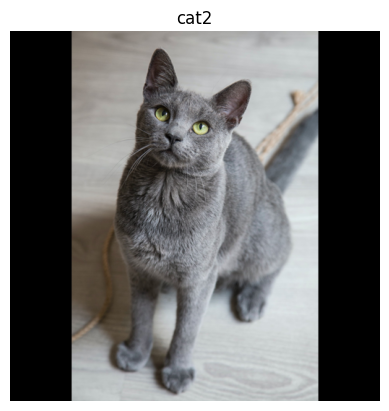

In [15]:
class_name_1 = 'cat2'
subject_image_1 = image_dict[class_name_1][0]
plt.figure()
plt.imshow(subject_image_1)
plt.title(class_name_1)
plt.axis("off")
plt.show()
class_name_1 = 'cat'

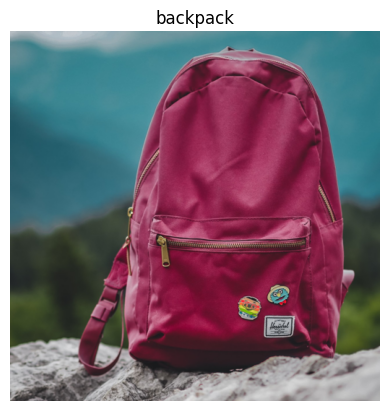

In [18]:
class_name_2 = 'backpack'
subject_image_2 = image_dict[class_name_2][2]
plt.figure()
plt.imshow(subject_image_2)
plt.title(class_name_2)
plt.axis("off")
plt.show()

In [19]:
subject_image_tensor_gpu_1 = general_utils.image_to_tensor(subject_image_1).to(device=device)
subject_image_tensor_gpu_2 = general_utils.image_to_tensor(subject_image_2).to(device=device)

## Mask Example

In [ ]:
masks = get_mask(object_detector, sam_processor, sam_model, subject_image_1, "")

mask = masks[0].cpu().numpy() if hasattr(masks[0], 'cpu') else masks[0]
mask = masks[0]  # shape: (3, H, W)
# Experiment with different channels
if mask.ndim == 3 and mask.shape[0] == 3:
    mask = mask[0]
plt.figure()
plt.imshow(mask)
plt.title("Mask")
plt.axis("off")
plt.show()

In [ ]:
masks = get_mask(object_detector, sam_processor, sam_model, subject_image_1, class_name)

mask = masks[0].cpu().numpy() if hasattr(masks[0], 'cpu') else masks[0]
mask = masks[0]  # shape: (3, H, W)
# Experiment with different channels
if mask.ndim == 3 and mask.shape[0] == 3:
    mask = mask[0]
plt.figure()
plt.imshow(mask)
plt.title("Mask")
plt.axis("off")
plt.show()

# Getting subject image DINO and IR feature vectors

In [20]:
##### SUBJECT IMAGE 1
## Feed Subject Image to Dino
dino_subject_image_input_1 = dino_utils.prepare_for_dino(subject_image_tensor_gpu_1, transforms_configs).cuda()
with torch.no_grad():
    dino_subject_image_features_1 = dino_utils.get_dino_features(
        dino, dino_subject_image_input_1
    )

## Feed Subject Image to IR
with torch.no_grad():
    ir_subject_image_features_1 = ir_features_utils.get_ir_features(
        ir_feature_extractor, feature_extractor_transforms, subject_image_tensor_gpu_1
    )

##### SUBJECT IMAGE 2
## Feed Subject Image to Dino
dino_subject_image_input_2 = dino_utils.prepare_for_dino(subject_image_tensor_gpu_2, transforms_configs).cuda()
with torch.no_grad():
    dino_subject_image_features_2 = dino_utils.get_dino_features(
        dino, dino_subject_image_input_2
    )

## Feed Subject Image to IR
with torch.no_grad():
    ir_subject_image_features_2 = ir_features_utils.get_ir_features(
        ir_feature_extractor, feature_extractor_transforms, subject_image_tensor_gpu_2
    )

/content/drive/Othercomputers/My MacBook Pro/SISO_original/SISO_reimplemented/dino_utils.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(transforms_configs["normalize_mean"], device=image.device),
/content/drive/Othercomputers/My MacBook Pro/SISO_original/SISO_reimplemented/dino_utils.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(transforms_configs["normalize_std"], device=image.device),


Till here GPU RAM is 11.7Gb

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Optimizing cat:   0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Optimizing cat:   2%|▏         | 1/50 [00:01<01:09,  1.41s/it]

Loss 0: -0.3078552782535553


...

  0%|          | 0/1 [00:00<?, ?it/s]

Optimizing cat: 100%|██████████| 50/50 [00:49<00:00,  1.00it/s]

Loss 49: -1.7380001544952393


  0%|          | 0/4 [00:00<?, ?it/s]

Final Image after denoising step: 


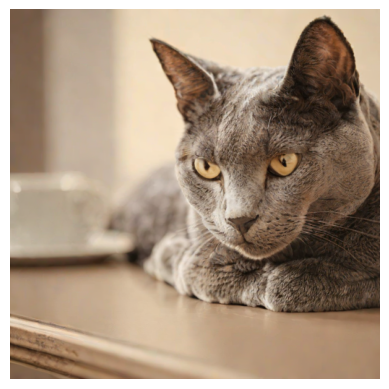

First Image after 1st train step: 


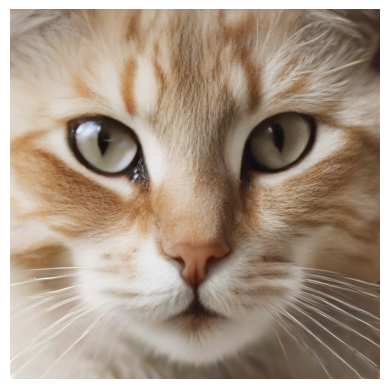

Last Image after 50th train step 


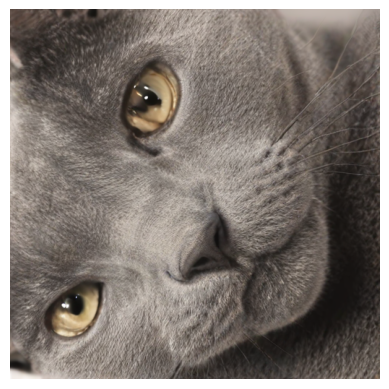

In [21]:
# Running the Diffusion Loop for first subject:
torch.cuda.empty_cache()
gc.collect()
PYTORCH_CUDA_ALLOC_CONF=True
pipeline = StableDiffusionXLPipelineWithGrads.from_pretrained(
        model_path,
        vae=vae,
        text_encoder=text_encoder,
        text_encoder_2=text_encoder_2,
        unet=unet
    ).to(device)

STOPPING_ITER = 50
prompt =f"Image of a {class_name_1}"

first_image = None
best_loss = float("inf")
best_image = None

for iter in trange(STOPPING_ITER, desc=f"Optimizing {class_name_1}"):
    optimizer.zero_grad()

    generator = torch.Generator(device=accelerator.device)
    generator.manual_seed(42)
  # generate image
  # with accelerator.accumulate(unet):
    image = (pipeline(
                  prompt=prompt,
                  num_inference_steps=1,
                  output_type="pt",
                  height=512,
                  width=512,
                  generator=generator,
                  guidance_scale=0.0,
              )
              .images[0]
              .unsqueeze(0))
    # Save first image
    if iter == 0:
      first_image = image

    dino_loss_1 = dino_criterion(
                      dino,
                      transforms_configs,
                      image,
                      dino_subject_image_features_1
                  )

    ir_loss_1 = ir_criterion(
                ir_feature_extractor,
                feature_extractor_transforms,
                image,
                ir_subject_image_features_1,
            )

    loss = dino_loss_1 * dino_weight + ir_loss_1 * ir_weight

    # save best loss/image
    if abs(loss.detach().item()) < abs(best_loss):
      best_loss = loss.detach().item()
      best_image = image

    # finetune model
    accelerator.backward(loss)
    optimizer.step()

    print(f"Loss {iter}: {loss.detach().item()}")

prompt =f"Image of a {class_name_1} on table"
with torch.no_grad():
  fimage = (pipeline(
                    prompt=prompt,
                    num_inference_steps=4,
                    output_type="pt",
                    height=512,
                    width=512,
                    generator=generator,
                    guidance_scale=0.0,
                )
                .images[0]
                .unsqueeze(0))
print("Final Image after denoising step: ")
plt.imshow(fimage.detach().cpu().squeeze().permute(1,2,0))
plt.axis('off')
plt.show()
print("First Image after 1st train step: ")
plt.imshow(first_image.detach().cpu().squeeze().permute(1,2,0))
plt.axis('off')
plt.show()
print(f"Last Image after {STOPPING_ITER}th train step ")
plt.imshow(image.detach().cpu().squeeze().permute(1,2,0))
plt.axis('off')
plt.show()

Optimizing backpack:   0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Optimizing backpack:   2%|▏         | 1/60 [00:01<00:59,  1.02s/it]

Loss 0: -0.6667124032974243


  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

Optimizing backpack: 100%|██████████| 60/60 [01:00<00:00,  1.00s/it]

Loss 59: -1.6386146545410156


  0%|          | 0/4 [00:00<?, ?it/s]

Final Image after denoising step: 


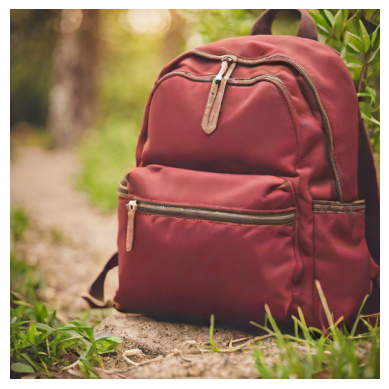

First Image after 1st train step: 


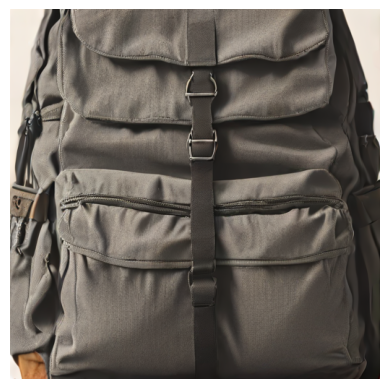

Last Image after 60th train step 


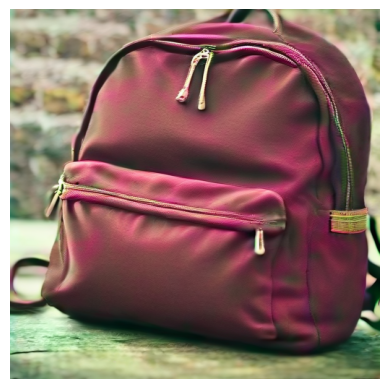

In [22]:
# Running the Diffusion Loop for first subject:
torch.cuda.empty_cache()
gc.collect()
STOPPING_ITER = 60
prompt =f"Image of a {class_name_2}"

first_image = None
best_loss = float("inf")
best_image = None

for iter in trange(STOPPING_ITER, desc=f"Optimizing {class_name_2}"):
    optimizer.zero_grad()

    generator = torch.Generator(device=accelerator.device)
    generator.manual_seed(42)
  # generate image
  # with accelerator.accumulate(unet):
    image = (pipeline(
                  prompt=prompt,
                  num_inference_steps=1,
                  output_type="pt",
                  height=512,
                  width=512,
                  generator=generator,
                  guidance_scale=0.0,
              )
              .images[0]
              .unsqueeze(0))
    # Save first image
    if iter == 0:
      first_image = image

    dino_loss_2 = dino_criterion(
                      dino,
                      transforms_configs,
                      image,
                      dino_subject_image_features_2
                  )

    ir_loss_2 = ir_criterion(
                ir_feature_extractor,
                feature_extractor_transforms,
                image,
                ir_subject_image_features_2,
            )

    loss = dino_loss_2 * dino_weight + ir_loss_2 * ir_weight

    # save best loss/image
    if abs(loss.detach().item()) < abs(best_loss):
      best_loss = loss.detach().item()
      best_image = image

    # finetune model
    accelerator.backward(loss)
    optimizer.step()

    print(f"Loss {iter}: {loss.detach().item()}")

prompt =f"Image of a {class_name_2}"
with torch.no_grad():
  fimage = (pipeline(
                    prompt=prompt,
                    num_inference_steps=4,
                    output_type="pt",
                    height=512,
                    width=512,
                    generator=generator,
                    guidance_scale=0.0,
                )
                .images[0]
                .unsqueeze(0))
print("Final Image after denoising step: ")
plt.imshow(fimage.detach().cpu().squeeze().permute(1,2,0))
plt.axis('off')
plt.show()
print("First Image after 1st train step: ")
plt.imshow(first_image.detach().cpu().squeeze().permute(1,2,0))
plt.axis('off')
plt.show()
print(f"Last Image after {STOPPING_ITER}th train step ")
plt.imshow(image.detach().cpu().squeeze().permute(1,2,0))
plt.axis('off')
plt.show()

  0%|          | 0/8 [00:00<?, ?it/s]

Final Image after 30th denoising step: 


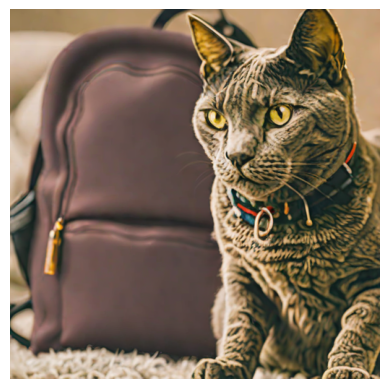

In [90]:
torch.cuda.empty_cache()
gc.collect()
prompt =f"Image of a {class_name_1} next to {class_name_2}"
with torch.no_grad():
  fimage = (pipeline(
                    prompt=prompt,
                    num_inference_steps=8,
                    output_type="pt",
                    height=512,
                    width=512,
                    generator=generator,
                    guidance_scale=0.0,
                )
                .images[0]
              .unsqueeze(0))
print("Final Image after 30th denoising step: ")
plt.imshow(fimage.detach().cpu().squeeze().permute(1,2,0))
plt.axis('off')
plt.show()

  0%|          | 0/8 [00:00<?, ?it/s]

Final Image after 30th denoising step: 


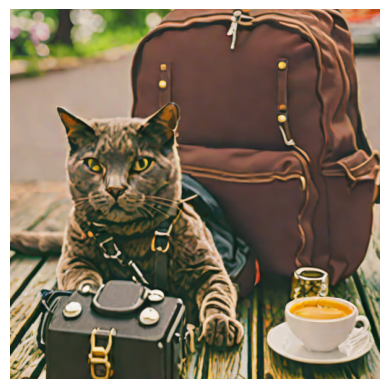

In [79]:
torch.cuda.empty_cache()
gc.collect()
prompt =f"Image of a {class_name_1} and {class_name_2} chilling with coffee"
with torch.no_grad():
  fimage = (pipeline(
                    prompt=prompt,
                    num_inference_steps=8,
                    output_type="pt",
                    height=512,
                    width=512,
                    generator=generator,
                    guidance_scale=0,
                )
                .images[0]
                .unsqueeze(0))
print("Final Image after 30th denoising step: ")
plt.imshow(fimage.detach().cpu().squeeze().permute(1,2,0))
plt.axis('off')
plt.show()


  0%|          | 0/8 [00:00<?, ?it/s]

Final Image after 30th denoising step: 


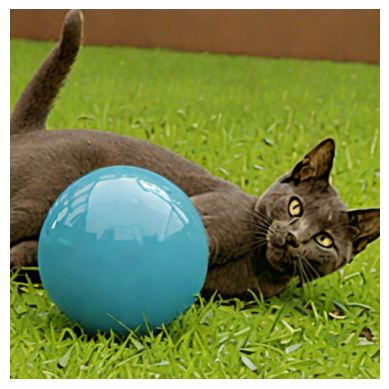

In [63]:
prompt =f"Image of a {class_name_1} with blue ball"
fimage = (pipeline(
                  prompt=prompt,
                  num_inference_steps=4,
                  output_type="pt",
                  height=512,
                  width=512,
                  generator=generator,
                  guidance_scale=0.0,
              )
              .images[0]
              .unsqueeze(0))
print("Final Image after 30th denoising step: ")
plt.imshow(fimage.detach().cpu().squeeze().permute(1,2,0))
plt.axis('off')
plt.show()

In [ ]:
torch.cuda.empty_cache()
accelerator.free_memory()


# Loading dataset into model - memory issue for now

In [ ]:
#subject_image_ir_ready = feature_extractor_transforms(subject_image_arr)

In [ ]:
#subject_image_ir_ready.shape

In [ ]:
from tqdm import trange

In [ ]:
## Training LOOP

In [ ]:
for class_name, images in image_dict.items():

  # currently only using the first image of each category as a subject
   if class_name =='backpack':
    continue
   if 0 in images:
      subject_image = images[0]
      print("Current Subject Image")
      plt.figure()
      plt.imshow(subject_image)
      plt.title(class_name)
      plt.axis("off")
      plt.show()
      subject_image_arr = general_utils.image_to_tensor(subject_image)

      # Getting Dino and IR image feature vectors from subject image :

      dino_model_path = "vit_large_patch14_dinov2.lvd142m"
      dino_criterion  = dino_utils.get_dino_features_negative_mean_cos_sim
      dino, transforms_configs = (dino_utils.get_model_and_transforms_configs(dino_model_path))
      dino_subject_image_input = dino_utils.prepare_for_dino(subject_image_arr, transforms_configs).cuda()
      with torch.no_grad():
          dino_subject_image_features = dino_utils.get_dino_features(
              dino, dino_subject_image_input
          )

      ## IR Loss
      new_path = path + "/arcface all vith 18 last and middle first 3 280 all 3 290 first 1 overlap last 6 middle 6 first 3 dropout.pth"

      ir_criterion = ir_features_utils.get_ir_features_negative_mean_cos_sim
      ir_feature_extractor, feature_extractor_transforms = (
                ir_features_utils.get_ir_model_and_transforms(
                    new_path,
                    #"third_party/IR_dependencies/ir_features.pth",
                    device=device
                )
            )
      ir_feature_extractor.eval()
      ir_feature_extractor = ir_feature_extractor.to(device)
      # subject_image_ir_ready = feature_extractor_transforms(subject_image_arr)
      with torch.no_grad():
          ir_subject_image_features = ir_features_utils.get_ir_features(
              ir_feature_extractor, feature_extractor_transforms, subject_image_arr
          )


      # Running the Diffusion Loop for first subject:
      PYTORCH_CUDA_ALLOC_CONF=True
      pipeline = StableDiffusionXLPipelineWithGrads.from_pretrained(
              model_path,
              vae=vae,
              text_encoder=text_encoder,
              text_encoder_2=text_encoder_2,
              unet=unet
          ).to(device)

      STOPPING_ITER = 30
      prompt =f"Image of a {class_name}"

      first_image = None
      best_loss = float("inf")
      best_image = None
      generator = torch.Generator(device=accelerator.device)
      generator.manual_seed(42)
      for iter in trange(STOPPING_ITER, desc=f"Optimizing {class_name}"):
          optimizer.zero_grad()


        # generate image
        # with accelerator.accumulate(unet):
          image = (pipeline(
                        prompt=prompt,
                        num_inference_steps=6,
                        output_type="pt",
                        height=336,
                        width=336,
                        generator=generator,
                        guidance_scale=0.0,
                    )
                    .images[0]
                    .unsqueeze(0))
          # Save first image
          if iter == 0:
            first_image = image

          # calculate loss
          dino_loss = dino_criterion(
                            dino,
                            transforms_configs,
                            image,
                            dino_subject_image_features,
                        )
          ir_loss = ir_criterion(
                      ir_feature_extractor,
                      feature_extractor_transforms,
                      image,
                      ir_subject_image_features,
                  )
          loss = dino_loss * dino_weight + ir_loss * ir_weight

          # save best loss/image
          if abs(loss.detach().item()) < abs(best_loss):
            best_loss = loss.detach().item()
            best_image = image

          # finetune model
          accelerator.backward(loss)
          optimizer.step()

          print(f"Loss {iter}: {loss.detach().item()}")

      prompt =f"Image of a {class_name} near beach"
      fimage = (pipeline(
                        prompt=prompt,
                        num_inference_steps=30,
                        output_type="pt",
                        height=336,
                        width=336,
                        generator=generator,
                        guidance_scale=0.0,
                    )
                    .images[0]
                    .unsqueeze(0))
      print("Final Image after 30th denoising step: ")
      plt.imshow(fimage.detach().cpu().squeeze().permute(1,2,0))
      plt.axis('off')
      plt.show()
      print("First Image after 1st train step: ")
      plt.imshow(first_image.detach().cpu().squeeze().permute(1,2,0))
      plt.axis('off')
      plt.show()
      print("Last Image after 30th train step ")
      plt.imshow(image.detach().cpu().squeeze().permute(1,2,0))
      plt.axis('off')
      plt.show()



In [ ]:
print("Last Image after 30th denoising step: ")
plt.imshow(best_image.detach().cpu().squeeze().permute(1,2,0))
plt.axis('off')
plt.show()